# Product Recognition on Store Shelves Project
## Computer Vision and Image Processing
### Alex Iborra Lérida

### Step A - Multiple Product Detection:
Develop an object detection system to identify single instance of products given: one reference image for
each item and a scene image. The system should be able to correctly identify all the product in the shelves
image. One way to solve this task could be the use of local invariant feature as explained in lab session 5.

First the approach of Lab Session 5 is used to confirm that a single detection is done

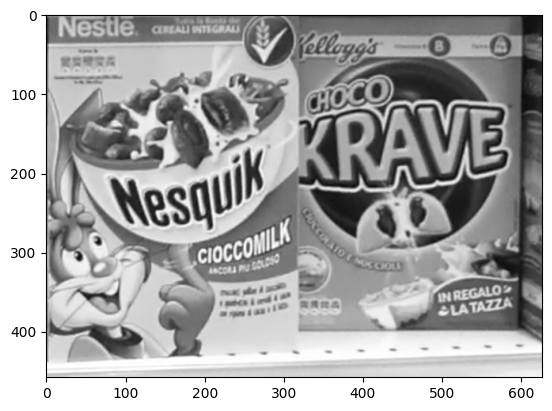

In [24]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import math
import os

img_train = cv2.imread("scenes/e1.png",0) # trainImage

plt.imshow(img_train, cmap='gray',vmin=0,vmax=255)
plt.show()

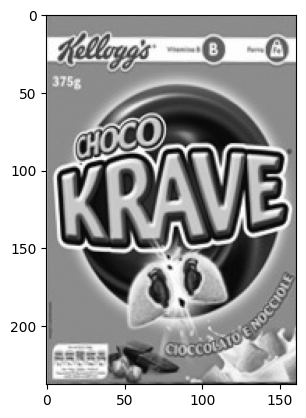

In [25]:
img_query = cv2.imread('models/11.jpg',0) # queryImage

plt.imshow(img_query, cmap='gray',vmin=0,vmax=255)
plt.show()

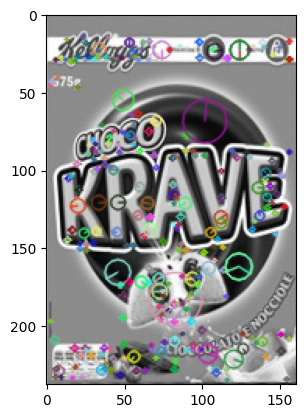

In [26]:
sift = cv2.SIFT_create()
kp_query = sift.detect(img_query)
img_visualization = cv2.drawKeypoints(img_query,kp_query,None,flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_visualization)
plt.show()

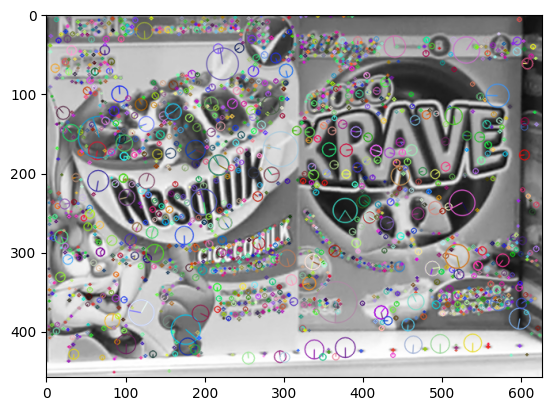

In [27]:
kp_train = sift.detect(img_train)
img=cv2.drawKeypoints(img_train,kp_train,None,flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img)
plt.show()


Product 0: 1 instance found: 
  Instance 1 position: (444,170), width: 304 px, height: 393 px


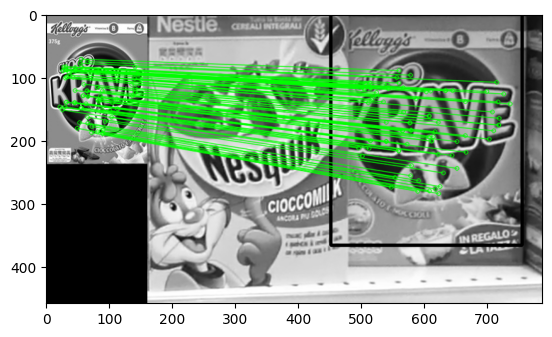

In [28]:
kp_query, des_query = sift.compute(img_query, kp_query)
kp_train, des_train = sift.compute(img_train, kp_train)

# Defining index for approximate kdtree algorithm
FLANN_INDEX_KDTREE = 1

# Defining parameters for algorithm 
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)

# Defining search params.
search_params = dict(checks = 100)

# Initializing matcher
flann = cv2.FlannBasedMatcher(index_params, search_params)

# Matching and finding the 2 closest elements for each query descriptor.
matches = flann.knnMatch(des_query,des_train,k=2)

good = []

for m,n in matches:
    if m.distance < 0.7*n.distance:
        good.append(m)


# Checking if we found enough matching
MIN_MATCH_COUNT = 10
if len(good)>MIN_MATCH_COUNT:
    # building the corrspondences arrays of good matches
    src_pts = np.float32([ kp_query[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
    dst_pts = np.float32([ kp_train[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
    # Using RANSAC to estimate a robust homography. 
    # It returns the homography M and a mask for the discarded points
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    
    # Mask of discarded point used in visualization
    matchesMask = mask.ravel().tolist()
    
    # Corners of the query image
    h,w = img_query.shape
    pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
    # Projecting the corners into the train image
    dst = cv2.perspectiveTransform(pts,M)
    
    # Transformation to square BB
    #Left
    if dst[0,0,0] < dst[1,0,0]:
         dst[1,0,0] = dst[0,0,0]
    else: 
        dst[0,0,0] = dst[1,0,0]

    #Right
    if dst[2,0,0] > dst[3,0,0]:
         dst[3,0,0] = dst[2,0,0]
    else: 
        dst[2,0,0] = dst[3,0,0]    

    #Up
    if dst[0,0,1] < dst[3,0,1]:
         dst[3,0,1] = dst[0,0,1]
    else: 
        dst[0,0,1] = dst[3,0,1]

    #Down
    if dst[2,0,1] > dst[1,0,1]:
         dst[1,0,1] = dst[2,0,1]
    else: 
        dst[2,0,1] = dst[1,0,1] 

    height_bb = round(np.linalg.norm(dst[0]-dst[1]))
    width_bb = round(np.linalg.norm(dst[0]-dst[3]))
    x_center = round(dst[0,0,0] + width_bb/2)
    y_center = round(dst[0,0,1] + height_bb/2)
    # Drawing the bounding box
    img_train = cv2.polylines(img_train,[np.int32(dst)],True,(0, 0, 255),3, cv2.LINE_AA)
    
    print('Product 0: 1 instance found: \n  Instance 1 position: ({},{}), width: {} px, height: {} px'.format(x_center,y_center,width_bb,height_bb))

else:
    print( "Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_COUNT) )
    matchesMask = None
    # Drawing the matches
draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                   singlePointColor = None, # not draw keypoints only matching lines
                   matchesMask = matchesMask, # draw only inliers
                   flags = 2) # not draw keypoints only lines
img3 = cv2.drawMatches(img_query,kp_query,img_train,kp_train,good,None,**draw_params)
plt.imshow(img3)
plt.show()






## It proved that it works, so now with all the models and scenes


In [29]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

def produce_outputs(img_train_vector, img_query_vector, MIN_MATCH_COUNT = 20, checks = 100):
    
    # Cycle through all scene images
    for i, path in enumerate(img_train_vector):

        #Load image
        img_train = cv2.imread('scenes/'+path,0)

        # Initiate SIFT detector
        sift = cv2.SIFT_create()

        # Find the keypoints and descriptors with SIFT
        kp_train = sift.detect(img_train)

        # Describe keypoints
        kp_train, des_train = sift.compute(img_train, kp_train)

        print('\nScene image {}: {}'.format(i+1,path))
        produce_query(img_query_vector, sift, kp_train, des_train, img_train, MIN_MATCH_COUNT, checks)

        

def produce_query(img_query_vector, sift, kp_train, des_train, img_train, MIN_MATCH_COUNT, n_checks):
    
    # Cycle through all model images
    for i, path in enumerate(img_query_vector):

        #Load image
        img_query = cv2.imread('models/'+path,0)
        kp_query = sift.detect(img_query)
        kp_query, des_query = sift.compute(img_query, kp_query)

        # Defining index for approximate kdtree algorithm
        FLANN_INDEX_KDTREE = 1
        index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)

        # Defining search params
        search_params = dict(checks = n_checks)

        # Initializing matcher
        flann = cv2.FlannBasedMatcher(index_params, search_params)

        # Matching and finding the 2 closest elements for each query descriptor.
        matches = flann.knnMatch(des_query,des_train,k=2)

        # Filter out ratio between closest and second closest elements
        good = []
        for m,n in matches:
            if m.distance < 0.7*n.distance:
                good.append(m)

        # Enough good matches check
        if len(good)>MIN_MATCH_COUNT:
            
            # Building the corrspondences arrays of good matches
            src_pts = np.float32([ kp_query[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
            dst_pts = np.float32([ kp_train[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
            
            # Using RANSAC to estimate a robust homography. 
            M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0) 
            
            # Corners of the query image
            h,w = img_query.shape
            pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
            dst = cv2.perspectiveTransform(pts,M)

            # Generate rectangular bounding box that encloses cereal box
            # Left
            if dst[0,0,0] < dst[1,0,0]:
                dst[1,0,0] = dst[0,0,0]
            else: 
                dst[0,0,0] = dst[1,0,0]

            # Right
            if dst[2,0,0] > dst[3,0,0]:
                dst[3,0,0] = dst[2,0,0]
            else: 
                dst[2,0,0] = dst[3,0,0]    

            # Up
            if dst[0,0,1] < dst[3,0,1]:
                dst[3,0,1] = dst[0,0,1]
            else: 
                dst[0,0,1] = dst[3,0,1]

            # Down
            if dst[2,0,1] > dst[1,0,1]:
                dst[1,0,1] = dst[2,0,1]
            else: 
                dst[2,0,1] = dst[1,0,1] 

            # Obtain output parameters from found box
            height_bb = round(np.linalg.norm(dst[0]-dst[1]))
            width_bb = round(np.linalg.norm(dst[0]-dst[3]))
            x_center = round(dst[0,0,0] + width_bb/2)
            y_center = round(dst[0,0,1] + height_bb/2)
            
            print('Product {} ({}): 1 instance found: \n Instance 1 position: ({},{}), width: {} px, height: {} px'.format(i+1, path, x_center, y_center, width_bb, height_bb))
            print('------------------------------------------------')
        
        else:
            print("Product {} ({}): 0 instance found".format(i+1, path) )
            print('------------------------------------------------')
           

In [30]:
MIN_MATCH_COUNT = 110
n_checks = 200
img_train_vector = ['e1.png', 'e2.png', 'e3.png', 'e4.png', 'e5.png']

img_query_vector = ['0.jpg', '1.jpg', '11.jpg', '19.jpg', '24.jpg', '26.jpg', '25.jpg']
produce_outputs(img_train_vector, img_query_vector, MIN_MATCH_COUNT, checks = n_checks)


Scene image 1: e1.png
Product 1 (0.jpg): 1 instance found: 
 Instance 1 position: (163,217), width: 311 px, height: 444 px
------------------------------------------------
Product 2 (1.jpg): 1 instance found: 
 Instance 1 position: (444,166), width: 297 px, height: 387 px
------------------------------------------------
Product 3 (11.jpg): 0 instance found
------------------------------------------------
Product 4 (19.jpg): 0 instance found
------------------------------------------------
Product 5 (24.jpg): 0 instance found
------------------------------------------------
Product 6 (26.jpg): 0 instance found
------------------------------------------------
Product 7 (25.jpg): 0 instance found
------------------------------------------------

Scene image 2: e2.png
Product 1 (0.jpg): 1 instance found: 
 Instance 1 position: (571,168), width: 260 px, height: 358 px
------------------------------------------------
Product 2 (1.jpg): 0 instance found
--------------------------------------

### *First Issue*: Using greyscale images and only SIFT will make similar cereal boxes be mistakenly identified. For example:

<function matplotlib.pyplot.show(close=None, block=None)>

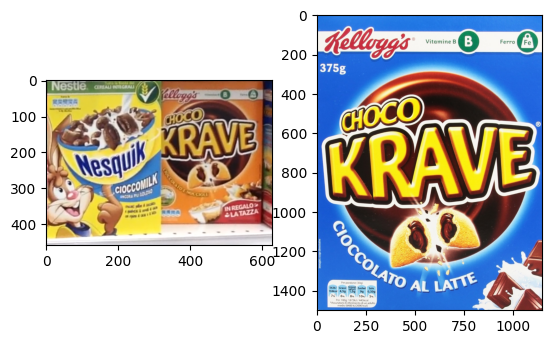

In [31]:
img_scene_mistaken = cv2.imread('scenes/e1.png')
img_scene_mistaken = cv2.cvtColor(img_scene_mistaken, cv2.COLOR_BGR2RGB)

img_model_mistaken = cv2.imread('models/1.jpg')
img_model_mistaken = cv2.cvtColor(img_model_mistaken, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(img_scene_mistaken)
plt.subplot(1,2,2)
plt.imshow(img_model_mistaken)
plt.show



### *Solution*: Include colour as a threshold variable through means across colour channels and Mahalanobis distance between model image and the crop of the scene image
Add the brightness normalisation before computing the pixel statistics -> This makes color matching lighting-invariant

In [32]:
# ── Mahalanobis colour similarity helper ──────────────────────────────────────
def mahalanobis_color_distance(img_color_query, img_color_scene_crop):
    """
    Compare the colour of a scene crop against a query model using Mahalanobis
    distance on mean BGR pixel values.

    Both images are brightness-normalised (divided by their own global mean)
    before comparison, making the distance invariant to per-scene lighting
    differences while preserving hue/saturation ratios between channels.

    Returns:
        distance (float) – lower is more similar.
    """
    # Flatten to (N, 3) float arrays
    pixels_query = img_color_query.reshape(-1, 3).astype(np.float64)
    pixels_crop  = img_color_scene_crop.reshape(-1, 3).astype(np.float64)

    # ── Brightness normalisation ───────────────────────────────────────────────
    # Divide each image by its own overall mean pixel value so that both are
    # mapped to ≈1.0 average brightness, cancelling per-scene lighting shifts
    # without discarding colour ratios (hue/saturation information is kept).
    pixels_query /= (pixels_query.mean() + 1e-6)
    pixels_crop  /= (pixels_crop.mean()  + 1e-6)

    # Mean and covariance from the brightness-normalised query image
    mu    = pixels_query.mean(axis=0)          # shape (3,)
    sigma = np.cov(pixels_query, rowvar=False)  # shape (3,3)

    # Regularise covariance to avoid singular matrix
    sigma += np.eye(3) * 1e-6

    sigma_inv = np.linalg.inv(sigma)

    # Mean colour of the brightness-normalised scene crop
    x = pixels_crop.mean(axis=0)               # shape (3,)

    diff = x - mu
    dist = np.sqrt(diff @ sigma_inv @ diff)
    return dist


def _filter_keypoints_outside_poly(kp, des, polygon):
    """
    Return (kp_kept, des_kept) — keypoints whose position lies OUTSIDE `polygon`.
    `polygon` is a (4,1,2) float32 array as returned by perspectiveTransform.
    """
    poly = np.int32(polygon)  # (4,1,2)
    kept_kp  = []
    kept_des = []
    for k, d in zip(kp, des):
        pt = (int(k.pt[0]), int(k.pt[1]))
        # pointPolygonTest returns > 0 if inside, 0 on edge, < 0 outside
        if cv2.pointPolygonTest(poly, pt, False) < 0:
            kept_kp.append(k)
            kept_des.append(d)
    if kept_des:
        return kept_kp, np.array(kept_des, dtype=np.float32)
    return [], None


def _straighten_bb(dst):
    """Straighten bounding-box corners in-place and return dst."""
    # Left
    if dst[0, 0, 0] < dst[1, 0, 0]:
        dst[1, 0, 0] = dst[0, 0, 0]
    else:
        dst[0, 0, 0] = dst[1, 0, 0]
    # Right
    if dst[2, 0, 0] > dst[3, 0, 0]:
        dst[3, 0, 0] = dst[2, 0, 0]
    else:
        dst[2, 0, 0] = dst[3, 0, 0]
    # Up
    if dst[0, 0, 1] < dst[3, 0, 1]:
        dst[3, 0, 1] = dst[0, 0, 1]
    else:
        dst[0, 0, 1] = dst[3, 0, 1]
    # Down
    if dst[2, 0, 1] > dst[1, 0, 1]:
        dst[1, 0, 1] = dst[2, 0, 1]
    else:
        dst[2, 0, 1] = dst[1, 0, 1]
    return dst


def produce_query(img_query_vector, sift,
                  kp_train, des_train,
                  img_train, img_train_color,
                  MIN_MATCH_COUNT, COLOR_THRESH,
                  MAX_RETRIES=3):
    """
    For each query model:
      1. Run SIFT matching against the full scene keypoint pool.
      2. If a geometric match is found but Mahalanobis rejects it (wrong colour),
         remove the scene keypoints inside that bounding box and retry (up to
         MAX_RETRIES times) so the correct colour variant can be found.
    """
    # COLOR_THRESH can be a scalar or a per-query list
    thresh_vector = COLOR_THRESH if isinstance(COLOR_THRESH, (list, tuple, np.ndarray))                     else [COLOR_THRESH] * len(img_query_vector)

    FLANN_INDEX_KDTREE = 1
    index_params  = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=100)

    for i, path in enumerate(img_query_vector):
        query_thresh = thresh_vector[i]
        # Load query in colour; keep a greyscale copy for SIFT
        query_path = os.path.join('models', path)
        img_query_color = cv2.imread(query_path)

        if img_query_color is None:
            print(f"Error: Could not load model image at {query_path}")
            continue

        img_query = cv2.cvtColor(img_query_color, cv2.COLOR_BGR2GRAY)
        kp_query = sift.detect(img_query)
        kp_query, des_query = sift.compute(img_query, kp_query)

        h, w = img_query.shape
        query_corners = np.float32([[0,0],[0,h-1],[w-1,h-1],[w-1,0]]).reshape(-1,1,2)

        # Working copies of the scene keypoint pool — shrunk on each colour rejection
        kp_scene  = list(kp_train)
        des_scene = des_train.copy()

        found      = False
        attempt    = 0

        while attempt <= MAX_RETRIES and not found:
            attempt += 1
            if des_scene is None or len(kp_scene) < MIN_MATCH_COUNT:
                break   # not enough scene keypoints left to match

            flann   = cv2.FlannBasedMatcher(index_params, search_params)
            matches = flann.knnMatch(des_query, des_scene, k=2)

            good = [m for m, n in matches if m.distance < 0.7 * n.distance]

            if len(good) <= MIN_MATCH_COUNT:
                break   # not enough inliers even before colour check

            src_pts = np.float32([kp_query[m.queryIdx].pt for m in good]).reshape(-1,1,2)
            dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1,1,2)
            M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

            if M is None:
                break

            dst = cv2.perspectiveTransform(query_corners, M)
            dst = _straighten_bb(dst)

            height_bb = round(np.linalg.norm(dst[0] - dst[1]))
            width_bb  = round(np.linalg.norm(dst[0] - dst[3]))
            x_center  = round(dst[0,0,0] + width_bb  / 2)
            y_center  = round(dst[0,0,1] + height_bb / 2)

            # ── Sanity check: reject degenerate bounding boxes ─────────────────
            MIN_BB_SIZE = 50
            if width_bb < MIN_BB_SIZE or height_bb < MIN_BB_SIZE:
                print('  [skip] Degenerate bbox ({}x{} px) – discarding match'.format(
                      width_bb, height_bb))
                break   # homography is fundamentally broken

            # ── Mahalanobis colour verification ───────────────────────────────
            x1 = max(0, int(dst[0,0,0]))
            y1 = max(0, int(dst[0,0,1]))
            x2 = min(img_train_color.shape[1], int(dst[3,0,0]))
            y2 = min(img_train_color.shape[0], int(dst[1,0,1]))

            if x2 > x1 and y2 > y1:
                scene_crop = img_train_color[y1:y2, x1:x2]
                dist       = mahalanobis_color_distance(img_query_color, scene_crop)
                colour_ok  = dist <= query_thresh
                colour_info = 'Mahalanobis dist = {:.4f} (thresh={})'.format(dist, query_thresh)
            else:
                colour_ok   = False
                colour_info = 'crop out-of-bounds – treated as rejection'

            if colour_ok:
                found = True
                img_train_color = cv2.polylines(
                    img_train_color, [np.int32(dst)], True, (0,0,255), 3, cv2.LINE_AA)
                print('Product {} ({}): 1 instance found [{}]: \n'
                      '  Instance 1 position: ({},{}), width: {} px, height: {} px'.format(
                          i+1, path, colour_info, x_center, y_center, width_bb, height_bb))
            else:
                # ── Colour rejected: remove matched region from the scene pool ──
                attempt_tag = '' if attempt == 1 else f' (attempt {attempt})'
                print('  [retry{}] Colour rejected at ({},{}) [{}] – removing region and retrying…'.format(
                      attempt_tag, x_center, y_center, colour_info))
                kp_scene, des_scene = _filter_keypoints_outside_poly(
                    kp_scene, des_scene, dst)

        if not found:
            print('Product {} ({}): 0 instance found'.format(i+1, path))
        print('------------------------------------------------')


def produce_outputs(img_train_vector, img_query_vector,
                    MIN_MATCH_COUNT=20, COLOR_THRESH=15.0):
    for i, path in enumerate(img_train_vector):
        # Load scene in colour; keep a greyscale copy for SIFT
        scene_path = os.path.join('scenes', path)
        img_train_color = cv2.imread(scene_path)
        
        if img_train_color is None:
            print(f"Error: Could not load scene image at {scene_path}")
            continue
            
        img_train = cv2.cvtColor(img_train_color, cv2.COLOR_BGR2GRAY)

        sift = cv2.SIFT_create()
        kp_train = sift.detect(img_train)
        kp_train, des_train = sift.compute(img_train, kp_train)

        print('\nScene image {}: {}'.format(i + 1, path))
        produce_query(img_query_vector, sift,
                      kp_train, des_train,
                      img_train, img_train_color,
                      MIN_MATCH_COUNT, COLOR_THRESH)


In [33]:
MIN_MATCH_COUNT = 73

img_train_vector = ['e1.png', 'e2.png', 'e3.png', 'e4.png', 'e5.png']
img_query_vector = ['0.jpg', '1.jpg', '11.jpg', '19.jpg', '24.jpg', '26.jpg', '25.jpg']

# Per-query Mahalanobis distance threshold — one value per entry in img_query_vector.
# Index:         0      1      2      3      4      5      6
#             0.jpg  1.jpg 11.jpg 19.jpg 24.jpg 26.jpg 25.jpg
COLOR_THRESH = [0.45,   0.92,   1.0,   1.0,   1.0,   0.28,   1.0]

produce_outputs(img_train_vector, img_query_vector, MIN_MATCH_COUNT, COLOR_THRESH)



Scene image 1: e1.png
Product 1 (0.jpg): 1 instance found [Mahalanobis dist = 0.1579 (thresh=0.45)]: 
  Instance 1 position: (163,218), width: 311 px, height: 444 px
------------------------------------------------
  [retry] Colour rejected at (445,165) [Mahalanobis dist = 1.0758 (thresh=0.92)] – removing region and retrying…
Product 2 (1.jpg): 0 instance found
------------------------------------------------
Product 3 (11.jpg): 1 instance found [Mahalanobis dist = 0.5912 (thresh=1.0)]: 
  Instance 1 position: (444,170), width: 303 px, height: 393 px
------------------------------------------------
Product 4 (19.jpg): 0 instance found
------------------------------------------------
Product 5 (24.jpg): 0 instance found
------------------------------------------------
  [retry] Colour rejected at (116,288) [Mahalanobis dist = 0.3093 (thresh=0.28)] – removing region and retrying…
Product 6 (26.jpg): 0 instance found
------------------------------------------------
Product 7 (25.jpg): 0 